# S&P 500 Equity Option Analytics: Feature Engineering

**Chapter 8: Feature Engineering**
**Section Reference**: 8.3 - Structural and Cross-Instrument Features

This notebook builds options-derived features for equity return prediction.
The strategy trades equities using IV surface information as alternative data.

## Feature Families (45 features)

Counts below reflect the `assign_feature_family` prefix rule used in the
evaluation section (a rank column such as `skew_rank` is grouped with its base
family, so the standalone Cross-Sectional Rank bucket is small).

| Family | Count | Description |
|--------|-------|-------------|
| IV Level & Dynamics | 13 | ATM IV, z-scores, percentiles, momentum |
| Skew & Term Structure | 9 | Risk reversal, term slope/ratio, convexity |
| Volatility / VRP | 9 | Realized vol, IV-RV spread, VRP z-scores |
| Equity Momentum | 7 | Multi-horizon returns, risk-adjusted momentum |
| Cross-Sectional Rank | 3 | Percentile-ranked features not absorbed by a base family |
| Quality / Liquidity | 2 | Convergence share, spread |
| Other | 2 | Uncategorized derived columns |

## Key Design Decisions
- **Delta-based** surface point selection (more stable than moneyness)
- **1-day IV lag** enforced for point-in-time correctness
- **No aggregate Greeks** (noise without OI data per review)
- **No put-call ratio** (misleading without volume per review)

## Cross-References
- **Upstream**: [`02_labels`](02_labels.ipynb) (label parquet files)
- **Downstream**: `04_temporal.py` (GARCH improves VRP), Ch11+ (ML models)

In [1]:
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import polars as pl

import utils.style  # noqa: F401  (activates the ML4T Plotly template)
from data import load_sp500_daily_bars, load_sp500_options_surface
from utils.paths import get_case_study_dir
from utils.style import ml4t_palette

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
YEARS = [2017, 2018, 2019, 2020, 2021]
START_DATE = "2017-01-01"
END_DATE = "2021-12-31"
MAX_SYMBOLS = 0

In [3]:
CASE_DIR = get_case_study_dir("sp500_equity_option_analytics")
FEATURES_DIR = CASE_DIR / "features"

In [4]:
# Date configuration
YEARS = [2017, 2018, 2019, 2020, 2021]
START_DATE = "2017-01-01"
END_DATE = "2021-12-31"

# Surface selection parameters
DTE_BUCKETS = {
    "7d": (5, 10),
    "30d": (25, 35),
    "90d": (80, 110),
}
DELTA_TARGETS = {
    "atm": 0.50,
    "25d": 0.25,
    "10d": 0.10,
}

print(f"Processing years: {YEARS}")
print(f"Date range: {START_DATE} to {END_DATE}")

Processing years: [2017, 2018, 2019, 2020, 2021]
Date range: 2017-01-01 to 2021-12-31


## 1. Load Equity Prices

Daily OHLCV for S&P 500 constituents. Used for realized vol, momentum
features, and joining with options-derived features.

In [5]:
daily = load_sp500_daily_bars(start_date=START_DATE, end_date=END_DATE)
daily = daily.sort(["symbol", "timestamp"])

print(f"Daily OHLCV: {daily.shape[0]:,} rows, {daily['symbol'].n_unique()} symbols")
print(f"Date range: {daily['timestamp'].min()} to {daily['timestamp'].max()}")

Daily OHLCV: 635,703 rows, 638 symbols
Date range: 2017-01-03 to 2021-12-31


## 2. Implied Volatility Surface Summary

The daily surface summary reduces ~70M option rows per year to one row per
(symbol, date). For each symbol and date, the summary selects the contract
closest to target delta within fixed DTE buckets:

| Bucket | DTE range | Delta target | Side |
| --- | --- | --- | --- |
| 30d ATM | 25-35 | 0.50 | C and P, averaged |
| 7d ATM | 5-10 | 0.50 | C or P (nearest) |
| 90d ATM | 80-110 | 0.50 | C or P (nearest) |
| 30d 25-delta put | 25-35 | 0.25 | P |
| 30d 25-delta call | 25-35 | 0.25 | C |

Derived features:

- `skew_rr_30_25d` — 25-delta risk reversal (put IV minus call IV)
- `term_slope_near_atm` — 30d ATM minus 7d ATM (short-to-medium segment;
  positive = contango at the short end)
- `term_slope_far_atm` — 90d ATM minus 30d ATM (medium-to-long segment;
  positive = contango at the long end)
- `term_ratio_atm` — 90d ATM / 7d ATM (scale-free full-curve slope)
- `term_convexity` — (7d + 90d) / 2 − 30d ATM (curve kink; positive means
  the 30d point sits below the midpoint of 7d and 90d)
- `skew_to_atm_ratio` — risk reversal normalized by ATM level
- `spread_atm_30` — relative bid-ask spread for the 30d ATM contract
- `qc_converged_share` — fraction of selected surface points where the IV
  solver converged

Each IV feature is one side of the volatility surface, selected and
normalized so that features are comparable across symbols with different
volatility levels, strike ladders, and expiration calendars. The
implementation lives in `data/equities/market/sp500/materialize_options.py`.

In [6]:
options_features = load_sp500_options_surface(start_date=START_DATE, end_date=END_DATE).sort(
    ["timestamp", "symbol"]
)

print(f"Surface: {len(options_features):,} rows, {options_features['symbol'].n_unique()} symbols")
print(f"Date range: {options_features['timestamp'].min()} to {options_features['timestamp'].max()}")
print(f"Columns: {options_features.columns}")

Surface: 530,503 rows, 633 symbols
Date range: 2017-01-03 to 2021-12-31
Columns: ['timestamp', 'symbol', 'iv_30_atm', 'iv_7_atm', 'iv_90_atm', 'iv_30_put_25d', 'iv_30_call_25d', 'skew_rr_30_25d', 'spread_atm_30', 'qc_converged_share', 'term_slope_near_atm', 'term_slope_far_atm', 'term_ratio_atm', 'term_convexity', 'skew_to_atm_ratio']


## 3. Surface Dynamics

Compute rolling z-scores, percentile ranks, and momentum for surface features.
These capture how current IV compares to its recent history and cross-section.

In [7]:
def compute_surface_dynamics(df: pl.DataFrame) -> pl.DataFrame:
    """Add dynamics features: daily changes, z-scores, percentile ranks.

    Features added:
    - d_iv_30_atm, d_skew_rr_30_25d, d_term_ratio_atm: Daily changes
    - iv_30_atm_z_{63,252}: Rolling z-scores
    - iv_30_atm_pct_252: 252-day percentile rank (where IV stands in 1yr history)
    - iv_mom_{5,21}d: IV momentum (change over 5d/21d)
    - skew_rr_z_63: Skew z-score
    """
    df = df.sort(["symbol", "timestamp"])

    # Daily changes
    df = df.with_columns(
        (pl.col("iv_30_atm") - pl.col("iv_30_atm").shift(1).over("symbol")).alias("d_iv_30_atm"),
        (pl.col("skew_rr_30_25d") - pl.col("skew_rr_30_25d").shift(1).over("symbol")).alias(
            "d_skew_rr_30_25d"
        ),
        (pl.col("term_ratio_atm") - pl.col("term_ratio_atm").shift(1).over("symbol")).alias(
            "d_term_ratio_atm"
        ),
    )

    # IV momentum (multi-day changes)
    df = df.with_columns(
        (pl.col("iv_30_atm") - pl.col("iv_30_atm").shift(5).over("symbol")).alias("iv_mom_5d"),
        (pl.col("iv_30_atm") - pl.col("iv_30_atm").shift(21).over("symbol")).alias("iv_mom_21d"),
    )

    # Rolling z-scores
    for window in [63, 252]:
        df = df.with_columns(
            (
                (pl.col("iv_30_atm") - pl.col("iv_30_atm").rolling_mean(window).over("symbol"))
                / pl.col("iv_30_atm").rolling_std(window).over("symbol").clip(lower_bound=0.001)
            ).alias(f"iv_30_atm_z_{window}"),
        )

    # 63-day skew z-score
    df = df.with_columns(
        (
            (pl.col("skew_rr_30_25d") - pl.col("skew_rr_30_25d").rolling_mean(63).over("symbol"))
            / pl.col("skew_rr_30_25d").rolling_std(63).over("symbol").clip(lower_bound=0.001)
        ).alias("skew_rr_z_63"),
    )

    # 252-day IV percentile rank (rolling min/max approach)
    # Compute as (current - min) / (max - min) over trailing window
    df = df.with_columns(
        (
            (pl.col("iv_30_atm") - pl.col("iv_30_atm").rolling_min(252).over("symbol"))
            / (
                pl.col("iv_30_atm").rolling_max(252).over("symbol")
                - pl.col("iv_30_atm").rolling_min(252).over("symbol")
            ).clip(lower_bound=0.001)
        ).alias("iv_30_atm_pct_252"),
    )

    # 63-day term ratio z-score
    df = df.with_columns(
        (
            (pl.col("term_ratio_atm") - pl.col("term_ratio_atm").rolling_mean(63).over("symbol"))
            / pl.col("term_ratio_atm").rolling_std(63).over("symbol").clip(lower_bound=0.001)
        ).alias("term_ratio_z_63"),
    )

    return df

## 4. Realized Volatility and VRP

Compute realized vol from equity prices and the static VRP (IV - RV).
The dynamic VRP (IV - GARCH forecast) is computed in `04_temporal.py`.

In [8]:
def compute_equity_vol_features(daily_df: pl.DataFrame) -> pl.DataFrame:
    """Compute realized vol features from equity close prices.

    Features:
    - rv_20: 20-day close-to-close realized vol (annualized)
    - rv_63: 63-day realized vol (annualized)
    - gk_vol_21: 21-day Garman-Klass vol (uses OHLC, more efficient)
    - vol_of_vol: 21-day rolling std of daily returns std (vol clustering)
    """
    df = daily_df.sort(["symbol", "timestamp"])

    # Close-to-close returns
    df = df.with_columns(pl.col("close").pct_change().over("symbol").alias("_ret"))

    # Close-to-close realized vol
    df = df.with_columns(
        (pl.col("_ret").rolling_std(20).over("symbol") * (252**0.5)).alias("rv_20"),
        (pl.col("_ret").rolling_std(63).over("symbol") * (252**0.5)).alias("rv_63"),
    )

    # Garman-Klass vol (more efficient estimator using OHLC)
    # GK = sqrt(252/N * sum(0.5*(log(H/L))^2 - (2*log(2)-1)*(log(C/O))^2))
    df = df.with_columns(
        (
            0.5 * (pl.col("high") / pl.col("low")).log().pow(2)
            - (2 * np.log(2) - 1) * (pl.col("close") / pl.col("open")).log().pow(2)
        ).alias("_gk_daily")
    )
    df = df.with_columns(
        (pl.col("_gk_daily").rolling_mean(21).over("symbol").clip(lower_bound=0.0) * 252)
        .sqrt()
        .alias("gk_vol_21")
    )

    # Volatility-of-volatility (clustering measure)
    df = df.with_columns(pl.col("rv_20").rolling_std(21).over("symbol").alias("vol_of_vol_21"))

    # Realized skewness (21-day)
    # Using simple approach: mean of cubed standardized returns
    df = df.with_columns(
        (
            (
                pl.col("_ret")
                / pl.col("_ret").rolling_std(21).over("symbol").clip(lower_bound=0.0001)
            )
            .pow(3)
            .rolling_mean(21)
            .over("symbol")
        ).alias("realized_skew_21")
    )

    return df.select(
        [
            "timestamp",
            "symbol",
            "rv_20",
            "rv_63",
            "gk_vol_21",
            "vol_of_vol_21",
            "realized_skew_21",
        ]
    )

## 5. Equity Momentum Features

Multi-horizon price momentum, risk-adjusted momentum, and skip-recent
momentum (12-1 month). These complement IV features and test whether
IV adds information beyond price-based signals.

In [9]:
def compute_momentum_features(daily_df: pl.DataFrame) -> pl.DataFrame:
    """Compute equity momentum features with cross-sectional ranks.

    Features:
    - mom_{5,21,63,126,252}d: Raw returns at multiple lookbacks
    - mom_skip_recent: return from t-252 to t-21 (skip recent month)
    - mom_risk_adj_63: 63d return / 63d realized vol
    """
    df = daily_df.sort(["symbol", "timestamp"]).select(["timestamp", "symbol", "close"])

    # Compute returns for each lookback (clip(1e-8) guards against div-by-zero)
    lookbacks = [5, 21, 63, 126, 252]
    for lb in lookbacks:
        df = df.with_columns(
            (
                pl.col("close") / pl.col("close").shift(lb).over("symbol").clip(lower_bound=1e-8)
                - 1
            ).alias(f"mom_{lb}d")
        )

    # Skip-recent momentum (12-1 month, Jegadeesh and Titman 1993): the return
    # from t-252 to t-21. Returns compound, so the recent month is removed by
    # dividing prices, not by subtracting mom_21d from mom_252d.
    df = df.with_columns(
        (
            pl.col("close").shift(21).over("symbol")
            / pl.col("close").shift(252).over("symbol").clip(lower_bound=1e-8)
            - 1
        ).alias("mom_skip_recent")
    )

    # Risk-adjusted momentum: 63d return / 63d vol
    df = df.with_columns(pl.col("close").pct_change().over("symbol").alias("_ret"))
    df = df.with_columns(
        (pl.col("_ret").rolling_std(63).over("symbol") * (252**0.5)).alias("_rv_63")
    )
    df = df.with_columns(
        (pl.col("mom_63d") / pl.col("_rv_63").clip(lower_bound=0.01)).alias("mom_risk_adj_63")
    )

    return df.select(
        [
            "timestamp",
            "symbol",
            "mom_5d",
            "mom_21d",
            "mom_63d",
            "mom_126d",
            "mom_252d",
            "mom_skip_recent",
            "mom_risk_adj_63",
        ]
    )

## 6. Cross-Sectional Ranks

Rank features within each date's cross-section. Percentile ranks (0-100)
are more stationary than raw values and directly comparable across time.

**Note**: Ranks are computed on all symbols present on each date, not filtered
to the 90%-coverage eligible subset. This is acceptable because ranks only use
within-date ordering (no lookahead). Symbols with spotty IV may have noisy ranks,
but this is handled by coverage filtering in downstream modeling (Ch11+).

In [10]:
def compute_cross_sectional_ranks(df: pl.DataFrame) -> pl.DataFrame:
    """Add cross-sectional percentile ranks for key features.

    Computes rank / count * 100 (percentile) for each feature within each date.
    """
    rank_features = {
        "iv_30_atm": "iv_rank",
        "skew_rr_30_25d": "skew_rank",
        "ivrv_spread": "vrp_rank",
        "mom_21d": "mom_21d_rank",
        "mom_63d": "mom_63d_rank",
        "rv_20": "rv_rank",
        "iv_mom_21d": "iv_mom_rank",
        "d_iv_30_atm": "d_iv_rank",
    }

    rank_exprs = []
    for src_col, dst_col in rank_features.items():
        if src_col in df.columns:
            rank_exprs.append(
                (
                    pl.col(src_col).rank().over("timestamp")
                    / pl.col(src_col).count().over("timestamp")
                    * 100
                ).alias(dst_col)
            )

    if rank_exprs:
        df = df.with_columns(rank_exprs)

    return df

## 7. Apply 1-Day IV Lag

**Critical for point-in-time correctness**: End-of-day IV may not be
published until the next morning. Shift all IV-derived features by 1 day
so that features at date t use IV from date t-1.

In [11]:
# Apply 1-day lag to all options-derived columns
# After lag, row at date t has IV from date t-1 (available at t)
iv_cols = [c for c in options_features.columns if c not in ["timestamp", "symbol"]]

options_features = options_features.sort(["symbol", "timestamp"])

lag_exprs = [pl.col(c).shift(1).over("symbol").alias(c) for c in iv_cols]
options_features = options_features.with_columns(lag_exprs)

print(f"Applied 1-day IV lag to {len(iv_cols)} columns")
print(f"After lag: {options_features.drop_nulls().shape[0]:,} non-null rows")

# Forward-fill missing IV (max 5 days per setup.yaml missing_data_rule)
ffill_exprs = [pl.col(c).forward_fill(limit=5).over("symbol").alias(c) for c in iv_cols]
options_features = options_features.sort(["symbol", "timestamp"]).with_columns(ffill_exprs)
print(f"After forward-fill (limit=5): {options_features.drop_nulls().shape[0]:,} non-null rows")

# Note: setup.yaml specifies stale_quote_handling: flag_and_exclude_if_stale_gt_2_days.
# Full staleness detection (unchanged IV for >2 consecutive days) requires tracking
# IV changes per symbol-day. The qc_converged_share feature partially captures quality.
# Full staleness flagging is deferred to Ch11 data quality pipeline.

Applied 1-day IV lag to 13 columns
After lag: 132,575 non-null rows


After forward-fill (limit=5): 208,228 non-null rows


## 8. Add Surface Dynamics

Compute z-scores, percentile ranks, and momentum AFTER the IV lag.
This ensures dynamics are computed on lagged (available) data.

In [12]:
print("Computing surface dynamics...")
options_features = compute_surface_dynamics(options_features)
print("Added dynamics: z-scores, percentiles, IV momentum")

Computing surface dynamics...


Added dynamics: z-scores, percentiles, IV momentum


## 9. Equity Features

Compute realized vol and momentum from equity prices. These features
use close prices with no additional lag (T-1 close is available at T open).

In [13]:
vol_features = compute_equity_vol_features(daily)
print(f"Equity vol features: {len(vol_features):,} rows")

mom_features = compute_momentum_features(daily)
print(f"Momentum features: {len(mom_features):,} rows")

Equity vol features: 635,703 rows


Momentum features: 635,703 rows


## 10. Combine All Features

Join options surface features with equity vol and momentum features.
Then compute the static VRP (IV - RV) and cross-sectional ranks.

In [14]:
# Join options + vol + momentum
features = (
    options_features.join(vol_features, on=["timestamp", "symbol"], how="left")
    .join(mom_features, on=["timestamp", "symbol"], how="left")
    .sort(["timestamp", "symbol"])
)

# Compute static VRP (IV - RV)
features = features.with_columns(
    (pl.col("iv_30_atm") - pl.col("rv_20")).alias("ivrv_spread"),
)

# VRP z-score (63-day)
features = features.sort(["symbol", "timestamp"]).with_columns(
    (
        (pl.col("ivrv_spread") - pl.col("ivrv_spread").rolling_mean(63).over("symbol"))
        / pl.col("ivrv_spread").rolling_std(63).over("symbol").clip(lower_bound=0.001)
    ).alias("vrp_z_63"),
)

# Cross-sectional ranks
features = compute_cross_sectional_ranks(features)

print(f"\nCombined features: {features.shape}")
print(f"Columns ({len(features.columns)}): {sorted(features.columns)}")


Combined features: (530503, 47)
Columns (47): ['d_iv_30_atm', 'd_iv_rank', 'd_skew_rr_30_25d', 'd_term_ratio_atm', 'gk_vol_21', 'iv_30_atm', 'iv_30_atm_pct_252', 'iv_30_atm_z_252', 'iv_30_atm_z_63', 'iv_30_call_25d', 'iv_30_put_25d', 'iv_7_atm', 'iv_90_atm', 'iv_mom_21d', 'iv_mom_5d', 'iv_mom_rank', 'iv_rank', 'ivrv_spread', 'mom_126d', 'mom_21d', 'mom_21d_rank', 'mom_252d', 'mom_5d', 'mom_63d', 'mom_63d_rank', 'mom_risk_adj_63', 'mom_skip_recent', 'qc_converged_share', 'realized_skew_21', 'rv_20', 'rv_63', 'rv_rank', 'skew_rank', 'skew_rr_30_25d', 'skew_rr_z_63', 'skew_to_atm_ratio', 'spread_atm_30', 'symbol', 'term_convexity', 'term_ratio_atm', 'term_ratio_z_63', 'term_slope_far_atm', 'term_slope_near_atm', 'timestamp', 'vol_of_vol_21', 'vrp_rank', 'vrp_z_63']


## 11. Feature Coverage Summary

Report coverage for each feature. Features with low coverage may need
forward-fill or exclusion.

In [15]:
print("\nFeature Coverage:")
coverage_data = []
for col in sorted(features.columns):
    if col in ("timestamp", "symbol"):
        continue
    non_null = features.select(pl.col(col).is_not_null().sum())[0, 0]
    pct = non_null / len(features) * 100
    coverage_data.append({"feature": col, "non_null": non_null, "coverage_pct": pct})

coverage_df = pl.DataFrame(coverage_data).sort("coverage_pct", descending=True)
for row in coverage_df.iter_rows(named=True):
    print(f"  {row['feature']:30s}: {row['non_null']:>10,} ({row['coverage_pct']:5.1f}%)")

n_features = len([c for c in features.columns if c not in ("timestamp", "symbol")])
n_above_70 = coverage_df.filter(pl.col("coverage_pct") >= 70).height
n_below_70 = n_features - n_above_70
print(f"\nTotal features: {n_features}")
print(f"  Coverage >= 70%: {n_above_70} (pass downstream correctness gate)")
print(f"  Coverage <  70%: {n_below_70} (may be dropped in evaluation)")


Feature Coverage:
  mom_5d                        :    528,333 ( 99.6%)
  gk_vol_21                     :    520,144 ( 98.0%)
  rv_20                         :    520,144 ( 98.0%)
  rv_rank                       :    520,144 ( 98.0%)
  mom_21d                       :    519,771 ( 98.0%)
  mom_21d_rank                  :    519,771 ( 98.0%)
  vol_of_vol_21                 :    510,322 ( 96.2%)
  realized_skew_21              :    509,931 ( 96.1%)
  mom_63d                       :    499,407 ( 94.1%)
  mom_63d_rank                  :    499,407 ( 94.1%)
  mom_risk_adj_63               :    499,345 ( 94.1%)
  rv_63                         :    499,345 ( 94.1%)
  iv_30_atm                     :    481,333 ( 90.7%)
  iv_30_call_25d                :    481,333 ( 90.7%)
  iv_30_put_25d                 :    481,333 ( 90.7%)
  iv_rank                       :    481,333 ( 90.7%)
  qc_converged_share            :    481,333 ( 90.7%)
  skew_rank                     :    481,333 ( 90.7%)
  skew_rr

## 12. CV Configuration Reference

Features are computed on the full sample (acceptable for decision-time-observable
features). The CV config from `cv_config.json` defines the evaluation
splits used for IC testing and downstream modeling.

In [16]:
import yaml

cv_config_path = CASE_DIR / "config" / "cv_config.json"
if cv_config_path.exists():
    with open(cv_config_path) as f:
        cv_config = json.load(f)
    print(
        f"CV config: {cv_config['n_splits']} splits, "
        f"train={cv_config.get('train_size', 'N/A')}, test={cv_config.get('test_size', 'N/A')}"
    )
else:
    print("CV config not found - run 02_labels.py first")

CV config: 2 splits, train=2Y, test=1Y


## 13. Save Features

In [17]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

features_path = FEATURES_DIR / "financial.parquet"
features.write_parquet(features_path)
print(f"Saved financial.parquet ({features_path.stat().st_size / 1024 / 1024:.1f} MB)")
print(f"  Shape: {features.shape}")

Saved financial.parquet (95.7 MB)
  Shape: (530503, 47)


In [18]:
# Free memory from options processing pipeline before evaluation
import gc

for _var in [
    "daily",
    "options_features",
    "vol_features",
    "mom_features",
    "all_years",
    "coverage_df",
    "coverage_data",
]:
    if _var in dir() and _var in globals():
        del globals()[_var]

del features
gc.collect()
print("Memory freed; reloading features from disk for evaluation")

features = pl.read_parquet(FEATURES_DIR / "financial.parquet")
print(f"Reloaded features: {features.shape}")

Memory freed; reloading features from disk for evaluation


Reloaded features: (530503, 47)


## 14. Feature Evaluation (IC with HAC + FDR)

Compute per-feature information coefficient (Spearman rank correlation)
against the primary label (5d forward return). We apply HAC standard
errors (Newey-West) to account for overlapping returns and Benjamini-Hochberg
FDR correction for multiple testing.

**This is an in-sample descriptive diagnostic, not an out-of-sample estimate.**
The IC/FDR here is computed over the full 2017-2021 sample (including the 2021
holdout) and drives NO feature selection — every feature computed above is
written to `financial.parquet` regardless of its IC, and downstream modeling
applies its own walk-forward CV. The authoritative holdout-clean feature
evaluation is `05_evaluation.py`.

In [19]:
import plotly.graph_objects as go
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from scipy import stats as sp_stats

In [20]:
def compute_ic_vectorized(
    eval_df: pl.DataFrame, feature_cols: list[str], min_obs: int = 10
) -> pl.DataFrame:
    """Compute cross-sectional Spearman IC for all features in a single pass.

    Returns DataFrame with columns: date, feature, ic, n_obs.
    """
    # Rank features and forward_return per date for Spearman correlation
    rank_exprs = [pl.col(c).rank().over("timestamp").alias(f"_r_{c}") for c in feature_cols] + [
        pl.col("forward_return").rank().over("timestamp").alias("_r_fwd")
    ]

    ranked = eval_df.with_columns(rank_exprs)

    # Compute per-date Pearson of ranks (= Spearman of values) for each feature
    ic_records = []
    for feat in feature_cols:
        feat_ic = (
            ranked.filter(pl.col(feat).is_not_null() & pl.col("forward_return").is_not_null())
            .group_by("timestamp")
            .agg(
                pl.corr(f"_r_{feat}", "_r_fwd").alias("ic"),
                pl.len().alias("n_obs"),
            )
            .filter(pl.col("n_obs") >= min_obs)
            .drop_nulls("ic")
            .with_columns(pl.lit(feat).alias("feature"))
        )
        ic_records.append(feat_ic)

    return pl.concat(ic_records).sort(["feature", "timestamp"])


def compute_hac_stats(ic_series: np.ndarray) -> dict:
    """Compute HAC (Newey-West) adjusted stats for an IC time series."""
    n = len(ic_series)
    mean_ic = float(np.mean(ic_series))
    naive_se = float(np.std(ic_series, ddof=1) / np.sqrt(n))

    # Newey-West with bandwidth = floor(n^(1/3))
    bw = max(1, int(n ** (1 / 3)))
    gamma0 = np.var(ic_series, ddof=1)
    gamma_sum = 0.0
    for j in range(1, bw + 1):
        w = 1 - j / (bw + 1)  # Bartlett kernel
        gamma_j = np.mean((ic_series[j:] - mean_ic) * (ic_series[:-j] - mean_ic))
        gamma_sum += 2 * w * gamma_j
    hac_var = (gamma0 + gamma_sum) / n
    hac_se = float(np.sqrt(max(hac_var, 1e-20)))
    t_stat = mean_ic / hac_se if hac_se > 0 else 0.0
    p_value = float(2 * (1 - sp_stats.norm.cdf(abs(t_stat))))
    naive_t = mean_ic / naive_se if naive_se > 0 else 0.0

    return {
        "mean_ic": mean_ic,
        "hac_se": hac_se,
        "t_stat": t_stat,
        "p_value": p_value,
        "naive_se": naive_se,
        "naive_t_stat": naive_t,
    }

In [21]:
# Feature family assignment
def assign_feature_family(col: str) -> str:
    """Map feature column to family for analysis."""
    if col.startswith(("iv_30", "iv_7", "iv_90", "d_iv", "iv_mom")):
        return "iv_level_dynamics"
    elif col.startswith(("skew", "term", "iv_30_put", "iv_30_call")):
        return "skew_term"
    elif col.startswith(("rv_", "ivrv", "vrp", "gk_vol", "vol_of_vol", "realized_skew")):
        return "vrp"
    elif col.endswith("_rank"):
        return "cross_sectional_rank"
    elif col.startswith("mom_"):
        return "momentum"
    elif col.startswith(("qc_", "spread_")):
        return "quality"
    return "other"

In [22]:
# Load labels for evaluation
LABELS_DIR = CASE_DIR / "labels"
label_files = {
    "fwd_ret_5d": LABELS_DIR / "fwd_ret_5d.parquet",
    "fwd_ret_10d": LABELS_DIR / "fwd_ret_10d.parquet",
    "fwd_ret_risk_adj_5d": LABELS_DIR / "fwd_ret_risk_adj_5d.parquet",
}
label_dfs = {}
for name, path in label_files.items():
    if path.exists():
        label_dfs[name] = pl.read_parquet(path)
        print(f"Loaded {name}: {len(label_dfs[name]):,} rows")

feature_cols = [c for c in features.columns if c not in ("timestamp", "symbol")]

Loaded fwd_ret_5d: 632,508 rows
Loaded fwd_ret_10d: 629,343 rows
Loaded fwd_ret_risk_adj_5d: 619,887 rows


In [23]:
# Compute IC for all features across all horizons in a single pass each
# This replaces the slow per-feature loop with vectorized Polars group_by
ic_all_horizons = {}  # {horizon: {feature: {mean_ic, hac_stats...}}}

for label_name, label_df in label_dfs.items():
    label_col = label_name  # Column name matches file key (fwd_ret_5d, etc.)
    if label_col not in label_df.columns:
        continue

    eval_df = features.join(
        label_df.rename({label_col: "forward_return"}),
        on=["timestamp", "symbol"],
        how="inner",
    )
    ic_ts = compute_ic_vectorized(eval_df, feature_cols)
    del eval_df

    # Compute HAC stats per feature from IC time series
    horizon_results = {}
    for feat in feature_cols:
        feat_ic = ic_ts.filter(pl.col("feature") == feat)["ic"].drop_nulls().drop_nans().to_numpy()
        if len(feat_ic) < 10:
            continue
        hac = compute_hac_stats(feat_ic)
        if not np.isnan(hac["mean_ic"]):
            horizon_results[feat] = hac

    ic_all_horizons[label_name] = horizon_results
    del ic_ts
    print(f"  {label_name}: IC computed for {len(horizon_results)} features")

  fwd_ret_5d: IC computed for 45 features


  fwd_ret_10d: IC computed for 45 features


  fwd_ret_risk_adj_5d: IC computed for 45 features


In [24]:
# Primary label results (fwd_ret_5d) with family assignment
primary_label = "fwd_ret_5d"
ic_results = []
if primary_label in ic_all_horizons:
    for feat, hac in ic_all_horizons[primary_label].items():
        ic_results.append(
            {
                "name": feat,
                "family": assign_feature_family(feat),
                "ic_mean": round(hac["mean_ic"], 4),
                "hac_se": round(hac["hac_se"], 4),
                "hac_tstat": round(hac["t_stat"], 2),
                "hac_pval": round(hac["p_value"], 4),
                "naive_tstat": round(hac.get("naive_t_stat", 0), 2),
            }
        )

ic_df = pl.DataFrame(ic_results).sort("hac_pval") if ic_results else pl.DataFrame()
print(f"\nIC computed for {len(ic_df)} features against {primary_label}")
if len(ic_df) > 0:
    print(ic_df.head(15))


IC computed for 45 features against fwd_ret_5d
shape: (15, 7)
┌─────────────────────┬────────────────────┬─────────┬────────┬───────────┬──────────┬─────────────┐
│ name                ┆ family             ┆ ic_mean ┆ hac_se ┆ hac_tstat ┆ hac_pval ┆ naive_tstat │
│ ---                 ┆ ---                ┆ ---     ┆ ---    ┆ ---       ┆ ---      ┆ ---         │
│ str                 ┆ str                ┆ f64     ┆ f64    ┆ f64       ┆ f64      ┆ f64         │
╞═════════════════════╪════════════════════╪═════════╪════════╪═══════════╪══════════╪═════════════╡
│ term_ratio_atm      ┆ skew_term          ┆ 0.014   ┆ 0.0067 ┆ 2.07      ┆ 0.0383   ┆ 3.89        │
│ skew_to_atm_ratio   ┆ skew_term          ┆ 0.0079  ┆ 0.0049 ┆ 1.59      ┆ 0.1109   ┆ 3.06        │
│ term_slope_near_atm ┆ skew_term          ┆ 0.0077  ┆ 0.0049 ┆ 1.58      ┆ 0.1138   ┆ 2.78        │
│ qc_converged_share  ┆ quality            ┆ 0.0041  ┆ 0.0029 ┆ 1.43      ┆ 0.1518   ┆ 2.34        │
│ skew_rr_z_63        ┆ skew

The chart below ranks the features by absolute IC against the primary 5d label.
Even the strongest features sit near |IC| ~ 0.02-0.03, and (as the FDR step below
confirms) none survives multiple-testing correction: no single option-derived
feature carries a standalone edge at this sample size.

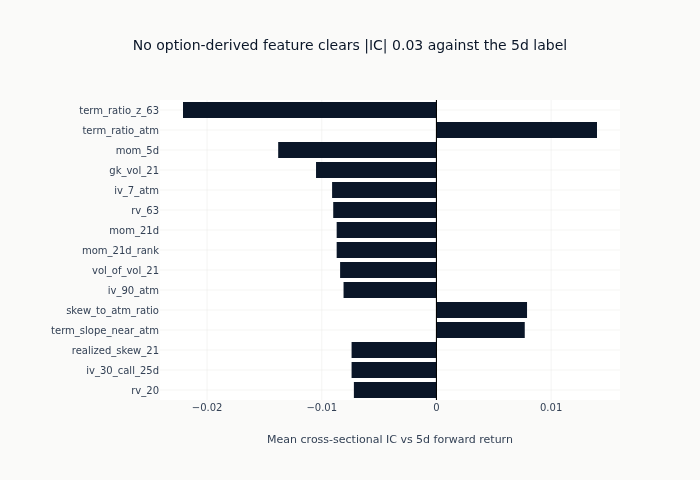

In [25]:
if len(ic_df) > 0:
    top_ic = (
        ic_df.with_columns(pl.col("ic_mean").abs().alias("abs_ic"))
        .sort("abs_ic", descending=True)
        .head(15)
    )
    fig = go.Figure()
    fig.add_bar(
        x=top_ic["ic_mean"].to_list(),
        y=top_ic["name"].to_list(),
        orientation="h",
        marker_color=ml4t_palette(1)[0],
    )
    fig.add_vline(x=0.0, line_width=1, line_color="black")
    fig.update_layout(
        title="No option-derived feature clears |IC| 0.03 against the 5d label",
        xaxis_title="Mean cross-sectional IC vs 5d forward return",
        yaxis_title=None,
        yaxis=dict(autorange="reversed"),
        margin=dict(l=160),
        height=480,
    )
    fig.show()

In [26]:
# BH-FDR correction
if len(ic_df) > 0:
    p_values = ic_df["hac_pval"].to_numpy()
    fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)

    n_naive_sig = int((p_values < 0.05).sum())
    n_fdr_sig = int(fdr_result["n_rejected"])
    inflation = round(n_naive_sig / max(n_fdr_sig, 1), 1) if n_fdr_sig > 0 else float(n_naive_sig)

    print("\nMultiple testing correction (BH-FDR at 5%):")
    print(f"  Naive significant (p < 0.05): {n_naive_sig}")
    print(f"  FDR significant: {n_fdr_sig}")
    print(f"  Inflation factor: {inflation}")
else:
    n_naive_sig, n_fdr_sig, inflation = 0, 0, 0.0


Multiple testing correction (BH-FDR at 5%):
  Naive significant (p < 0.05): 1
  FDR significant: 0
  Inflation factor: 1.0


In [27]:
# Dual-horizon comparison
dual_horizon_results = {}
for label_name, horizon_results in ic_all_horizons.items():
    abs_ics = [abs(h["mean_ic"]) for h in horizon_results.values()]
    dual_horizon_results[label_name] = round(float(np.nanmean(abs_ics)), 4) if abs_ics else 0.0

print("\nDual-horizon mean |IC|:")
for k, v in dual_horizon_results.items():
    print(f"  {k}: {v:.4f}")

# Count features where 10d |IC| > 5d |IC|
n_10d_better = 0
if "fwd_ret_5d" in ic_all_horizons and "fwd_ret_10d" in ic_all_horizons:
    ic_5d = {f: abs(h["mean_ic"]) for f, h in ic_all_horizons["fwd_ret_5d"].items()}
    ic_10d = {f: abs(h["mean_ic"]) for f, h in ic_all_horizons["fwd_ret_10d"].items()}
    n_10d_better = sum(1 for f in ic_5d if ic_10d.get(f, 0) > ic_5d[f])
    print(f"  Features where 10d |IC| > 5d |IC|: {n_10d_better}/{len(ic_5d)}")

# Free evaluation data
del label_dfs, ic_all_horizons
gc.collect()


Dual-horizon mean |IC|:
  fwd_ret_5d: 0.0053
  fwd_ret_10d: 0.0065
  fwd_ret_risk_adj_5d: 0.0123
  Features where 10d |IC| > 5d |IC|: 29/45


833

In [28]:
# Feature correlation analysis (sampled dates)
all_dates = features["timestamp"].unique().sort()
sampled_dates = all_dates.gather_every(5)
sampled = features.filter(pl.col("timestamp").is_in(sampled_dates)).select(feature_cols)

corr_matrix = sampled.to_pandas().corr(method="spearman")
high_corr_mask = (corr_matrix.abs() > 0.7) & (corr_matrix < 1.0)
n_high_corr = int(high_corr_mask.sum().sum() / 2)
max_corr = float(corr_matrix.where(corr_matrix < 1.0).abs().max().max())

print("\nFeature correlation (sampled every 5th date):")
print(f"  Pairs with |corr| > 0.7: {n_high_corr}")
print(f"  Max pairwise |corr|: {max_corr:.3f}")


Feature correlation (sampled every 5th date):
  Pairs with |corr| > 0.7: 53
  Max pairwise |corr|: 0.972


The Spearman correlation heatmap exposes the redundancy structure: blocks of
highly correlated features (IV level/z-score variants, the momentum ladder)
argue for models that tolerate collinearity rather than a naive additive stack.

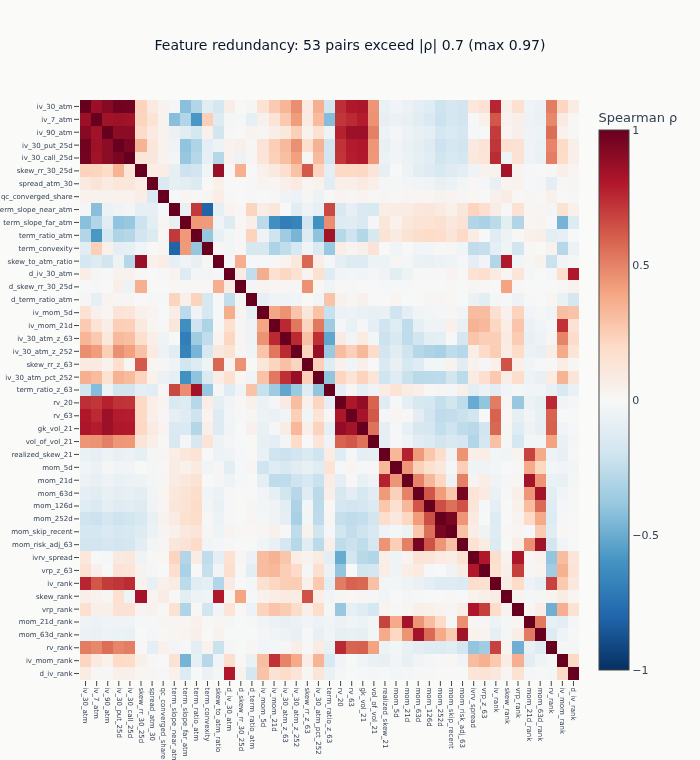

In [29]:
_ordered = [c for c in corr_matrix.columns]
fig = go.Figure(
    go.Heatmap(
        z=corr_matrix.loc[_ordered, _ordered].to_numpy(),
        x=_ordered,
        y=_ordered,
        zmin=-1,
        zmax=1,
        colorscale="RdBu",
        reversescale=True,
        colorbar=dict(title="Spearman ρ"),
    )
)
fig.update_layout(
    title=f"Feature redundancy: {n_high_corr} pairs exceed |ρ| 0.7 (max {max_corr:.2f})",
    height=760,
    xaxis=dict(tickfont=dict(size=7), tickangle=90),
    yaxis=dict(tickfont=dict(size=7), autorange="reversed"),
)
fig.show()
del sampled, corr_matrix

In [30]:
# IV vs Momentum family comparison
if len(ic_df) > 0:
    family_ic = {}
    for row in ic_results:
        fam = row["family"]
        family_ic.setdefault(fam, []).append(abs(row["ic_mean"]))
    family_avg_ic = {
        k: round(float(np.nanmean(v)), 4)
        for k, v in sorted(family_ic.items(), key=lambda x: -float(np.nanmean(x[1])))
    }

    iv_families = ["iv_level_dynamics", "skew_term", "vrp"]
    iv_avg = float(np.nanmean([family_avg_ic.get(f, 0) for f in iv_families]))
    mom_avg = float(family_avg_ic.get("momentum", 0))
    incremental_ic = round(iv_avg - mom_avg, 4)
    iv_beats = bool(incremental_ic > 0.005)

    print("\nIV vs Momentum:")
    print(f"  IV families avg |IC|: {iv_avg:.4f}")
    print(f"  Momentum avg |IC|:    {mom_avg:.4f}")
    print(f"  Incremental IC:       {incremental_ic}")
    print(f"  IV beats momentum by 0.005: {iv_beats}")
else:
    family_avg_ic = {}
    iv_avg, mom_avg, incremental_ic, iv_beats = 0, 0, 0, False


IV vs Momentum:
  IV families avg |IC|: 0.0062
  Momentum avg |IC|:    0.0045
  Incremental IC:       0.0017
  IV beats momentum by 0.005: False


Aggregating |IC| by feature family shows whether the option-derived families
(IV level/dynamics, skew/term, VRP) add information beyond equity momentum. The
IV families edge out momentum only marginally here (incremental mean |IC| is
small), which is why the multi-source design is tested through models rather than
claimed on single-feature IC alone.

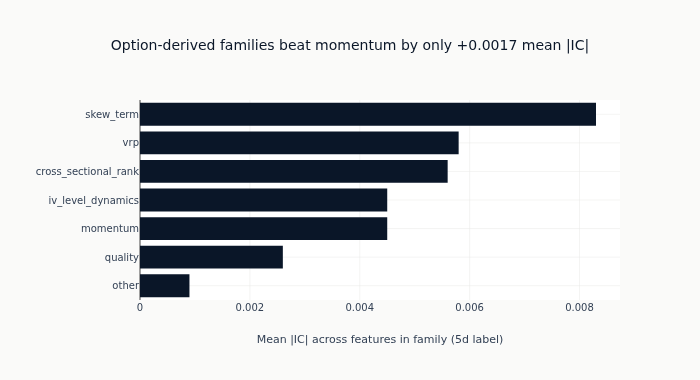

In [31]:
if family_avg_ic:
    fams = list(family_avg_ic.keys())
    fig = go.Figure()
    fig.add_bar(
        x=[family_avg_ic[f] for f in fams],
        y=fams,
        orientation="h",
        marker_color=ml4t_palette(1)[0],
    )
    fig.update_layout(
        title=(f"Option-derived families beat momentum by only {incremental_ic:+.4f} mean |IC|"),
        xaxis_title="Mean |IC| across features in family (5d label)",
        yaxis=dict(autorange="reversed"),
        margin=dict(l=140),
        height=380,
    )
    fig.show()

**Evaluation Summary**:
The feature evaluation reveals weak individual signal strength — no features
survive FDR correction at 5%, so no single feature carries a standalone edge at
this sample size. The 10d horizon shows marginally higher mean |IC| than 5d,
supporting the hypothesis that slower VRP accrual may improve viability.
IV-derived families (skew/term, VRP) show slightly higher mean |IC| than
momentum, but the incremental benefit is modest. These results motivate
careful model selection in Ch11 and potential horizon switching to 10d.

## Key Takeaways

1. **Surface summary approach** compresses millions of option rows into
   45 curated features per equity-day using delta-based contract selection.

2. **1-day IV lag** is applied BEFORE computing dynamics (z-scores, momentum),
   ensuring all features respect point-in-time constraints.

3. **Dropped noisy features** per strategic review: aggregate Greeks (need OI),
   put-call ratio (need volume), and gamma imbalance (need positioning data).

4. **Added missing features**: IV 252d percentile rank, skew-to-ATM ratio,
   term structure convexity, VRP z-score, Garman-Klass vol, vol-of-vol.

5. **Static VRP** (IV - RV) is the baseline. `04_temporal.py` improves this
   with GARCH-based conditional vol for a forward-looking VRP estimate.

**Next**: `04_temporal.py` fits GJR-GARCH per stock to produce `garch_cond_vol`
and `garch_ivrv_spread` as improved VRP features.